# 2 - Model Training

This notebook trains the CNN model on the MNIST dataset and visualizes the training process.

## 0 - Imports

In [8]:
import sys
import os

sys.path.append(os.path.join(os.path.abspath(""), "..", "src"))

import matplotlib.pyplot as plt
from data_loader import load_data, preprocess_data
from evaluate import plot_training_history
from model import build_model
from train import train

## 1 - Data loading and preprocessing

In [9]:
(X_train, y_train), (X_test, y_test) = load_data()
(X_train, y_train), (X_test, y_test) = preprocess_data(X_train, y_train, X_test, y_test)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (60000, 28, 28, 1)
X_test  : (10000, 28, 28, 1)


## 2 - Summary

In [10]:
model = build_model()
model.summary()

c:\Users\Ledge\cnn-mnist\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

## 3 - Training

In [11]:
model, history = train()

Epoch 1/20
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8044 - auc: 0.9640 - loss: 0.6690 - precision: 0.8591 - recall: 0.7591
Epoch 1: val_accuracy improved from None to 0.98417, saving model to c:\Users\Ledge\cnn-mnist\outputs\models\best_model.keras

Epoch 1: finished saving model to c:\Users\Ledge\cnn-mnist\outputs\models\best_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9000 - auc: 0.9907 - loss: 0.3280 - precision: 0.9293 - recall: 0.8790 - val_accuracy: 0.9842 - val_auc: 0.9988 - val_loss: 0.0573 - val_precision: 0.9860 - val_recall: 0.9830 - learning_rate: 0.0010
Epoch 2/20
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9572 - auc: 0.9969 - loss: 0.1439 - precision: 0.9642 - recall: 0.9507
Epoch 2: val_accuracy improved from 0.98417 to 0.98767, saving model to c:\Users\Ledge\cnn-mnist\outputs\models\best_model.keras

Epoch 2: finished saving model to c:\Users\Ledge\cnn-mnist\outputs\models\best_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━

## 4 - Training history

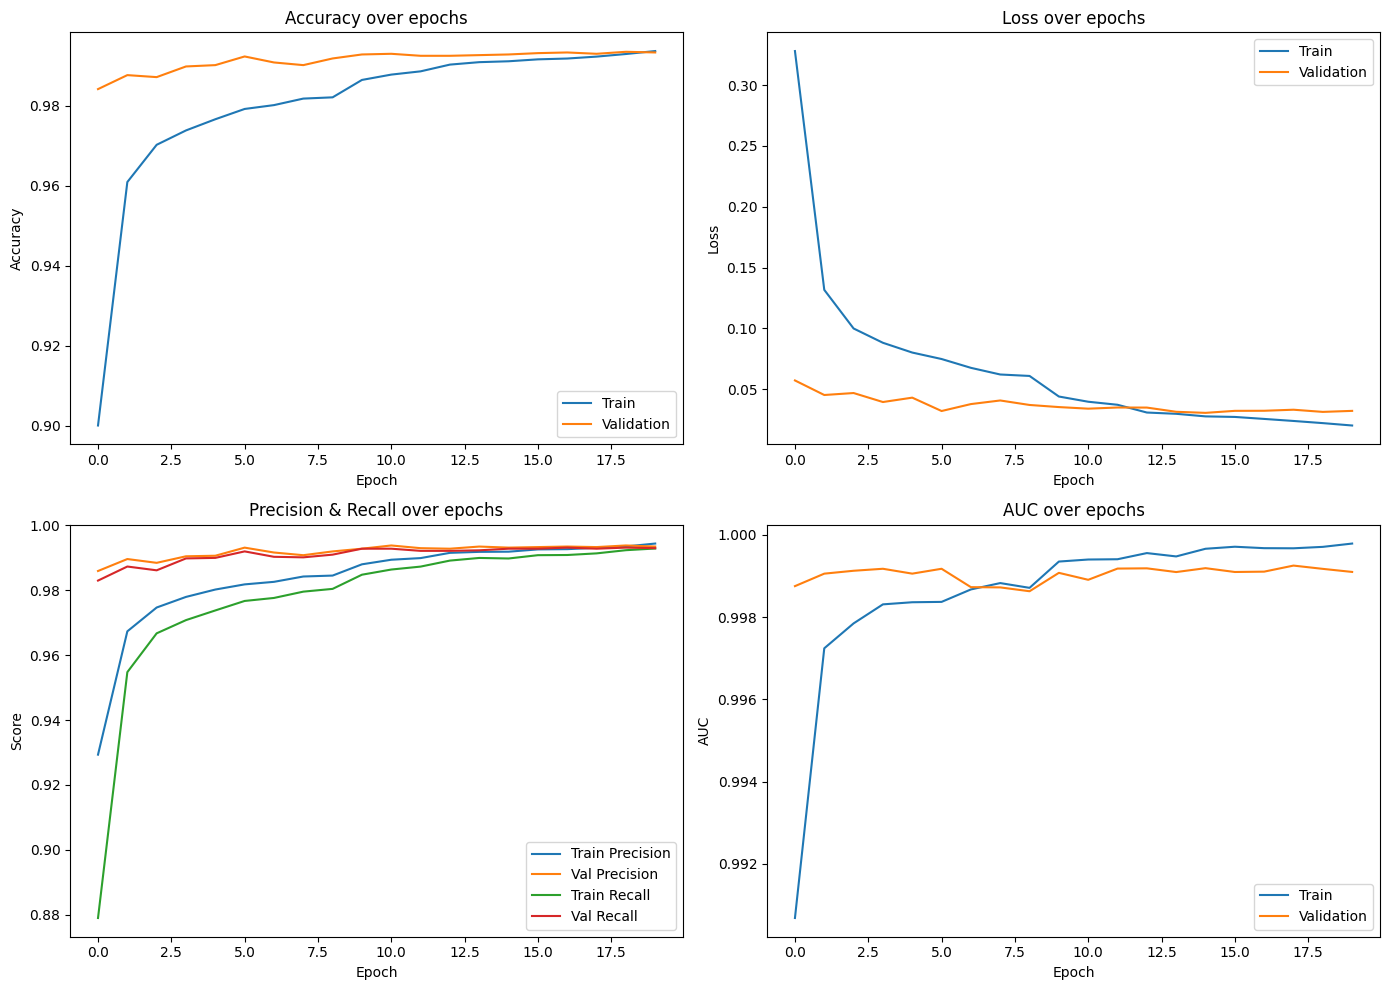

In [12]:
plot_training_history(history)